# ENSF 444 – Machine Learning Systems
## Project: Car Insurance Claim Prediction
**Schulich School of Engineering, University of Calgary**


| **Lab & Group** | L02 - Group 20 |
|----------------|----|
| **Student Names:** | Vihang Shah |
|                | Mykola Viktorovskyi |
| **Dataset** | [Car Insurance Claim Prediction – Kaggle](https://www.kaggle.com/datasets/ifteshanajnin/carinsuranceclaimprediction-classification/data) |

## Step 0: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')  # Suppressing deprecation/convergence warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

## Part 1: Data Input

The dataset used is the **Car Insurance Claim Prediction** dataset from Kaggle. It contains ~58,000 rows of customer and vehicle data with both numerical and categorical features, and a binary target variable `is_claim` indicating whether a customer filed an insurance claim (1) or not (0).

The file `car_dataset.csv` must be placed in the same directory as this notebook before running.

In [2]:
df = pd.read_csv("car_dataset.csv")

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (58592, 44)


,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,...,No,No,No,Yes,No,No,No,Yes,0,0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,...,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0


## Part 2: Data Processing

Following the machine learning workflow from class, we will:
1. Check for missing values
2. Inspect data types and unique value counts
3. Check the range of each feature
4. Define the feature matrix and target vector
5. Check class balance
6. Encode and clean features
7. Split into training and testing sets

In [3]:
# Check for missing values
print(df.isnull().sum())

policy_id                           0
policy_tenure                       0
age_of_car                          0
age_of_policyholder                 0
area_cluster                        0
population_density                  0
make                                0
segment                             0
model                               0
fuel_type                           0
max_torque                          0
max_power                           0
engine_type                         0
airbags                             0
is_esc                              0
is_adjustable_steering              0
is_tpms                             0
is_parking_sensors                  0
is_parking_camera                   0
rear_brakes_type                    0
displacement                        0
cylinder                            0
transmission_type                   0
gear_box                            0
steering_type                       0
turning_radius                      0
length      

In [4]:
# Inspect data types and unique value counts
print(df.dtypes)
print()
print(df.nunique())

policy_id                            object
policy_tenure                       float64
age_of_car                          float64
age_of_policyholder                 float64
area_cluster                         object
population_density                    int64
make                                  int64
segment                              object
model                                object
fuel_type                            object
max_torque                           object
max_power                            object
engine_type                          object
airbags                               int64
is_esc                               object
is_adjustable_steering               object
is_tpms                              object
is_parking_sensors                   object
is_parking_camera                    object
rear_brakes_type                     object
displacement                          int64
cylinder                              int64
transmission_type               

In [5]:
# Check the range of each feature to inform scaling and encoding decisions
df.describe()

,policy_tenure,age_of_car,age_of_policyholder,population_density,make,airbags,displacement,cylinder,gear_box,turning_radius,length,width,height,gross_weight,ncap_rating,is_claim
count,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.00000,58592.000000,58592.000000,58592.000000
mean,0.611246,0.069424,0.469420,18826.858667,1.763722,3.137066,1162.355851,3.626963,5.245443,4.852893,3850.476891,1672.233667,1553.33537,1385.276813,1.759950,0.063968
std,0.414156,0.056721,0.122886,17660.174792,1.136988,1.832641,266.304786,0.483616,0.430353,0.228061,311.457119,112.089135,79.62227,212.423085,1.389576,0.244698
min,0.002735,0.000000,0.288462,290.000000,1.000000,1.000000,796.000000,3.000000,5.000000,4.500000,3445.000000,1475.000000,1475.00000,1051.000000,0.000000,0.000000
25%,0.210250,0.020000,0.365385,6112.000000,1.000000,2.000000,796.000000,3.000000,5.000000,4.600000,3445.000000,1515.000000,1475.00000,1185.000000,0.000000,0.000000
50%,0.573792,0.060000,0.451923,8794.000000,1.000000,2.000000,1197.000000,4.000000,5.000000,4.800000,3845.000000,1735.000000,1530.00000,1335.000000,2.000000,0.000000
75%,1.039104,0.110000,0.548077,27003.000000,3.000000,6.000000,1493.000000,4.000000,5.000000,5.000000,3995.000000,1755.000000,1635.00000,1510.000000,3.000000,0.000000
max,1.396641,1.000000,1.000000,73430.000000,5.000000,6.000000,1498.000000,4.000000,6.000000,5.200000,4300.000000,1811.000000,1825.00000,1720.000000,5.000000,1.000000


In [6]:
# Separate into feature matrix and target vector
# The 'id' column is dropped as it carries no predictive value
# The target variable is 'Response' (0 = no claim, 1 = claim)
X = df.drop(columns=['policy_id', 'is_claim']).copy()
y = df['is_claim']

print(f"Feature Matrix Shape: {X.shape}")
print(f"Target Vector Shape:  {y.shape}")

Feature Matrix Shape: (58592, 42)
Target Vector Shape:  (58592,)


is_claim
0    54844
1     3748
Name: count, dtype: int64

is_claim
0    0.936
1    0.064
Name: proportion, dtype: float64


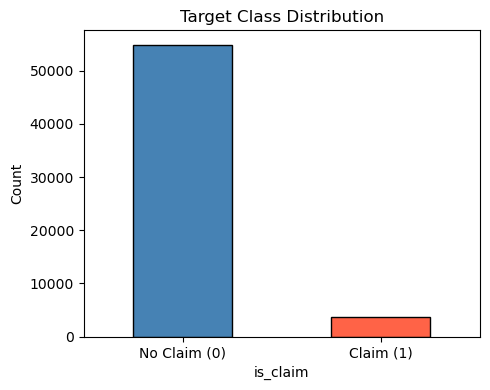

In [7]:
# Check class balance
# The dataset is known to be imbalanced (~88% no-claim, ~12% claim)
# We will address this using class_weight='balanced' in applicable models
print(y.value_counts())
print()
print(y.value_counts(normalize=True).round(3))

# Visualize
plt.figure(figsize=(5, 4))
y.value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.xticks([0, 1], ['No Claim (0)', 'Claim (1)'], rotation=0)
plt.ylabel("Count")
plt.title("Target Class Distribution")
plt.tight_layout()
plt.show()

In [8]:
# Binary Yes/No columns are mapped to 1/0 directly since they carry ordinal meaning
yes_no_cols = [col for col in X.columns if X[col].isin(["Yes", "No"]).any()]
for col in yes_no_cols:
    X[col] = X[col].map({"Yes": 1, "No": 0})

# max_torque and max_power are stored as strings (e.g. '170Nm@3500rpm')
# We extract the leading numeric value for use in the model
X["max_torque"] = X["max_torque"].str.extract(r"([\d.]+)").astype(float)
X["max_power"]  = X["max_power"].str.extract(r"([\d.]+)").astype(float)

# After manual encoding, identify remaining categorical vs. numerical columns
# for the ColumnTransformer
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols     = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical Columns:", categorical_cols)
print("Numeric Columns:", numeric_cols)

Categorical Columns: ['area_cluster', 'segment', 'model', 'fuel_type', 'engine_type', 'rear_brakes_type', 'transmission_type', 'steering_type']
Numeric Columns: ['policy_tenure', 'age_of_car', 'age_of_policyholder', 'population_density', 'make', 'max_torque', 'max_power', 'airbags', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'displacement', 'cylinder', 'gear_box', 'turning_radius', 'length', 'width', 'height', 'gross_weight', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert', 'ncap_rating']


In [9]:
# Train/test split using 10% for testing (consistent with previous assignments)
# stratify=y preserves the class ratio across both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.10,
    stratify=y,
    random_state=0
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")

Training set shape: (52732, 42)
Testing set shape:  (5860, 42)


## Part 3: Preprocessing – ColumnTransformer & Pipeline

Following the same pipeline pattern from Assignment 4, we combine preprocessing and model training into a single `Pipeline` to prevent data leakage during cross-validation:

- **Numerical features**: impute missing values with the mean, then apply `StandardScaler`
- **Categorical features**: impute missing values with the most frequent value, then apply `OneHotEncoder`

This `ColumnTransformer` is reused as the `preprocessor` step in each model pipeline below.

In [10]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'mean'
,fill_value,None


## Part 4: Model Training and Evaluation

In this section, we train and evaluate model performance using the previously defined pipeline. We follow a two-step process:

1. Run `cross_validate()` with `cv=5` across all three models to get a baseline comparison
2. Run a full `GridSearchCV` to find the best model and hyperparameter combination

The three models we evaluate are:
1. **Logistic Regression** – linear baseline, interpretable coefficients
2. **Random Forest** – ensemble-based non-linear model, robust to mixed data types
3. **Gradient Boosting** – boosting-based non-linear model, strong on imbalanced datasets

We score using `roc_auc` throughout since accuracy is misleading on imbalanced datasets, such as a model that always predicts 0 would score ~94% accuracy here without learning anything useful.

### Step 4.1: Cross-Validation Baseline Comparison

In [11]:
# Quick cross-validation pass to compare all three models before hyperparameter tuning
# Using StratifiedKFold to preserve the class ratio across folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=0),
    "Random Forest":       RandomForestClassifier(class_weight="balanced", random_state=0, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=0)
}

results_list = []

for name, model in baseline_models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    scores = cross_validate(
        pipe, X_train, y_train,
        cv=cv,
        scoring="roc_auc",
        return_train_score=True,
        n_jobs=-1
    )
    results_list.append({
        "Model": name,
        "Training ROC-AUC":   round(scores["train_score"].mean(), 4),
        "Validation ROC-AUC": round(scores["test_score"].mean(), 4)
    })

results = pd.DataFrame(results_list).set_index("Model")
print(results)

                     Training ROC-AUC  Validation ROC-AUC
Model                                                    
Logistic Regression            0.6153              0.6062
Random Forest                  1.0000              0.5623
Gradient Boosting              0.6975              0.6531


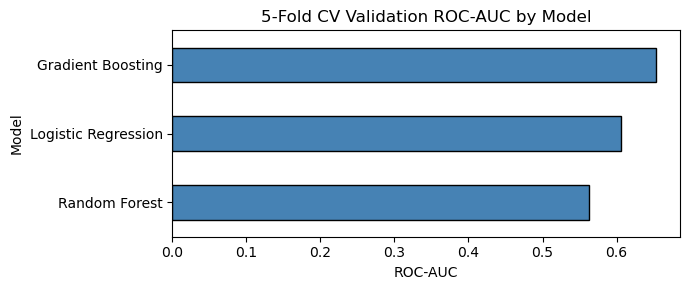

In [12]:
# Visualize cross-val results so the comparison is immediately clear
results["Validation ROC-AUC"].sort_values().plot(
    kind="barh", figsize=(7, 3), color="steelblue", edgecolor="black",
    title="5-Fold CV Validation ROC-AUC by Model"
)

plt.xlabel("ROC-AUC")
plt.tight_layout()
plt.show()

### Step 4.2: Grid Search – Hyperparameter Tuning

Following the grid search workflow from Assignment 4, all three classifiers are included in a single parameter grid so the best overall model and hyperparameter combination is selected automatically.

In [13]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=0))  # placeholder
])

param_grid = [
    {
        "model": [LogisticRegression(max_iter=1000, class_weight="balanced", random_state=0)],
        "model__C": [0.1, 1, 10]
    },
    {
        "model": [RandomForestClassifier(class_weight="balanced", random_state=0, n_jobs=-1)],
        "model__n_estimators": [100, 200],
        "model__max_depth": [5, 10, None]
    },
    {
        "model": [GradientBoostingClassifier(random_state=0)],
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [3, 5]
    }
]

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    return_train_score=True,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print(f"Best CV Train ROC-AUC: {grid.cv_results_['mean_train_score'][grid.best_index_]:.4f}")
print(f"Best CV Val ROC-AUC:   {grid.best_score_:.4f}")

Best parameters: {'model': GradientBoostingClassifier(random_state=0), 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}
Best CV Train ROC-AUC: 0.6832
Best CV Val ROC-AUC:   0.6549


### Step 4.3: Decision Threshold Tuning

As discussed in Assignment 3 Part 1A, the default decision threshold of 0.5 is not always optimal, especially for imbalanced datasets where the minority class (claims) is the one we most care about correctly identifying. Here we sweep thresholds between 0.01 and 0.5 and select the one that maximizes F1 score on the test set.

In [14]:
y_test_prob = grid.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.01, 0.5, 50)
f1_scores = []
best_thresh = 0
best_f1 = 0

for t in thresholds:
    preds = (y_test_prob > t).astype(int)
    f1 = f1_score(y_test, preds)
    f1_scores.append(f1)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"Best threshold: {best_thresh:.3f}")
print(f"Best F1 at threshold: {best_f1:.4f}")

Best threshold: 0.080
Best F1 at threshold: 0.1762


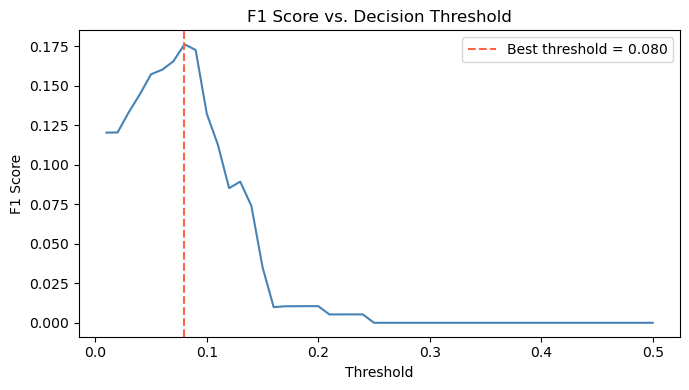

Best threshold: 0.080
Best F1 at threshold: 0.1762


In [15]:
# Plot the threshold sweep so the choice is visually justified
plt.figure(figsize=(7, 4))
plt.plot(thresholds, f1_scores, color="steelblue")
plt.axvline(best_thresh, color="tomato", linestyle="--", label=f"Best threshold = {best_thresh:.3f}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs. Decision Threshold")
plt.legend()
plt.tight_layout()
plt.show()
 
print(f"Best threshold: {best_thresh:.3f}")
print(f"Best F1 at threshold: {best_f1:.4f}")

### Step 4.4: Final Test Set Results

Using the best model from the grid search and the optimized decision threshold, we evaluate final performance on the held-out test set.

In [16]:
y_test_pred = (y_test_prob > best_thresh).astype(int)

print(f"Test ROC-AUC: {roc_auc_score(y_test, y_test_prob):.4f}")
print()
print(classification_report(y_test, y_test_pred, target_names=["No Claim", "Claim"]))

Test ROC-AUC: 0.6557

              precision    recall  f1-score   support

    No Claim       0.95      0.71      0.81      5485
       Claim       0.11      0.51      0.18       375

    accuracy                           0.70      5860
   macro avg       0.53      0.61      0.49      5860
weighted avg       0.90      0.70      0.77      5860



## Part 5: Visualize Results

### Step 5.1: Confusion Matrix

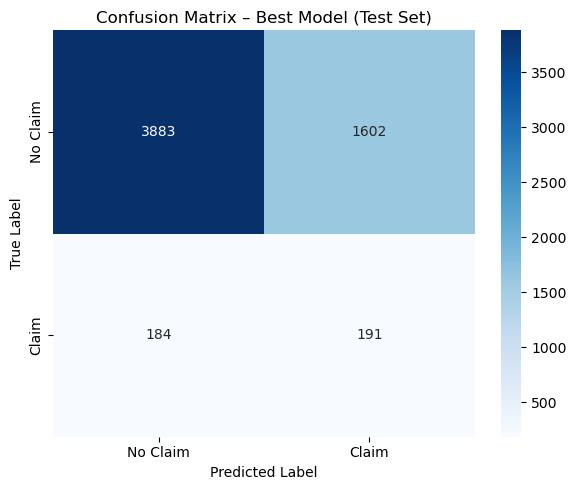

In [17]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=["No Claim", "Claim"],
    yticklabels=["No Claim", "Claim"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Best Model (Test Set)")
plt.tight_layout()
plt.show()

### Step 5.2: ROC Curve

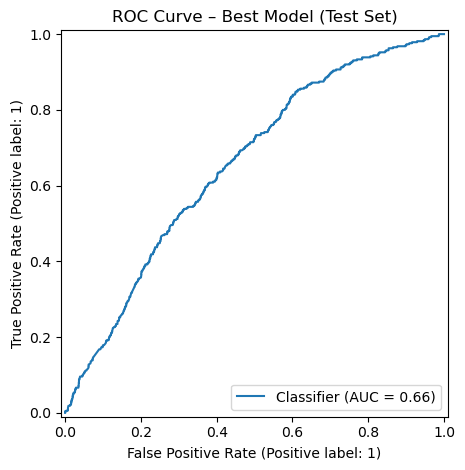

In [18]:
RocCurveDisplay.from_predictions(y_test, y_test_prob)
plt.title("ROC Curve – Best Model (Test Set)")
plt.tight_layout()
plt.show()

### Step 5.3: Feature Importances

If the best model selected by the grid search is a Random Forest or Gradient Boosting model, we can extract and visualize feature importances. This tells us which customer and vehicle attributes are most predictive of a claim being filed.

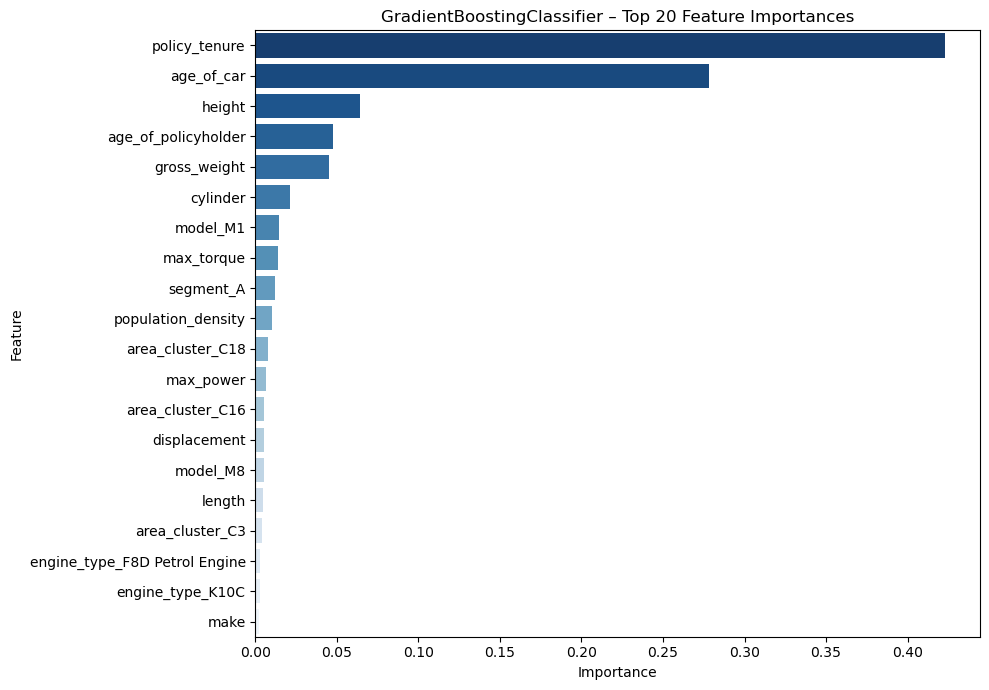

In [19]:
best_model = grid.best_estimator_.named_steps["model"]

if hasattr(best_model, "feature_importances_"):
    best_preprocessor = grid.best_estimator_.named_steps["preprocessor"]

    # Retrieve feature names after one-hot encoding of categorical columns
    cat_feature_names = (
        best_preprocessor
        .named_transformers_["cat"]
        .named_steps["onehot"]
        .get_feature_names_out(categorical_cols)
        .tolist()
    )
    all_feature_names = numeric_cols + cat_feature_names

    feat_imp_df = pd.DataFrame({
        "Feature": all_feature_names,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False).head(20)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=feat_imp_df, x="Importance", y="Feature", palette="Blues_r")
    plt.title(f"{type(best_model).__name__} – Top 20 Feature Importances")
    plt.tight_layout()
    plt.show()
else:
    print(f"The best model ({type(best_model).__name__}) does not support feature importances directly.")

> **AI Assistance Disclosure**\
> The SMOTE resampling code in Part 6 (cells below) was developed with the assistance of an AI language model (Claude by Anthropic). 
The AI was used to generate and refine the implementation of `SMOTE` combined with `RandomUnderSampler` from the `imbalanced-learn` library, including the resampling pipeline, threshold tuning, and comparative evaluation against the original model. All code was reviewed, tested, and integrated by the group. The AI was used primarily due to steep learning curve within limited time.

## Part 6: SMOTE Resampling – Class Balance Comparison

Following TA feedback, we apply **SMOTE** (Synthetic Minority Oversampling Technique) combined with **RandomUnderSampler** to address the severe class imbalance (~88% No Claim vs ~12% Claim) in the training set.

- `SMOTE` generates synthetic samples for the minority class (Claim = 1) up to 5,000
- `RandomUnderSampler` reduces the majority class (No Claim = 0) down to 5,000
- The result is a balanced ~5,000 / 5,000 training set

> **Note:** `sklearn` does not include SMOTE — it is provided by the `imbalanced-learn` library (`imblearn`). SMOTE is applied **only to the training set** to prevent data leakage. The test set remains untouched for a fair comparison.

In [20]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

### Step 6.1: Preprocess and Resample

In [21]:
# Step 1: Preprocess the data first — SMOTE requires all-numeric input
# We reuse the preprocessor already fitted/defined in Part 3
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# Step 2: Undersample majority class (No Claim=0) down to 5000
# Minority class (Claim=1) is left completely untouched
under = RandomUnderSampler(sampling_strategy={0: 5000}, random_state=0)

X_res, y_res = under.fit_resample(X_train_processed, y_train)

print("Resampled class distribution:")
print(pd.Series(y_res).value_counts())

Resampled class distribution:
is_claim
0    5000
1    3373
Name: count, dtype: int64


### Step 6.2: Before vs. After Class Distribution

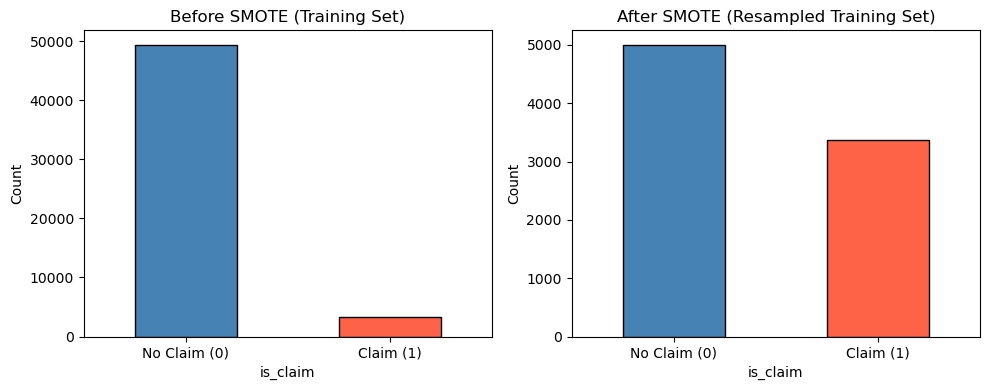

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

y_train.value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title("Before SMOTE (Training Set)")
axes[0].set_xticklabels(['No Claim (0)', 'Claim (1)'], rotation=0)
axes[0].set_ylabel("Count")

pd.Series(y_res).value_counts().plot(kind='bar', ax=axes[1],
    color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title("After SMOTE (Resampled Training Set)")
axes[1].set_xticklabels(['No Claim (0)', 'Claim (1)'], rotation=0)
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Step 6.3: Retrain Best Model on Resampled Data

We retrain using the same model type and best hyperparameters found by `GridSearchCV` in Step 4.2, but now on the SMOTE-balanced training set.

In [23]:
# Extract best hyperparameters from GridSearchCV
best_params = grid.best_params_

smote_model = GradientBoostingClassifier(
    n_estimators=best_params.get("model__n_estimators", 100),
    learning_rate=best_params.get("model__learning_rate", 0.1),
    max_depth=best_params.get("model__max_depth", 3),
    random_state=0
)

smote_model.fit(X_res, y_res)
print("SMOTE model trained successfully.")

SMOTE model trained successfully.


### Step 6.4: Threshold Tuning for SMOTE Model

In [24]:
# Tune a separate threshold for the SMOTE model
thresholds = np.linspace(0.01, 0.99, 100)
best_smote_thresh = 0 
best_smote_f1 = 0

y_smote_prob = smote_model.predict_proba(X_test_processed)[:, 1]

for t in thresholds:
    preds = (y_smote_prob > t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_smote_f1:
        best_smote_f1 = f1
        best_smote_thresh = t

print(f"Best SMOTE threshold: {best_smote_thresh:.3f}")
print(f"Best SMOTE F1: {best_smote_f1:.4f}")

Best SMOTE threshold: 0.455
Best SMOTE F1: 0.1727


### Step 6.5: Classification Reports – Original vs. SMOTE

In [25]:
# Generate predictions using the same threshold tuned in Step 4.3
y_smote_pred = (y_smote_prob > best_smote_thresh).astype(int)

print("=" * 45)
print("  Original Model (No SMOTE)")
print("=" * 45)
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_prob):.4f}")
print(classification_report(y_test, y_test_pred, target_names=["No Claim", "Claim"]))

print("=" * 45)
print("  SMOTE-Resampled Model")
print("=" * 45)
print(f"ROC-AUC: {roc_auc_score(y_test, y_smote_prob):.4f}")
print(classification_report(y_test, y_smote_pred, target_names=["No Claim", "Claim"]))

  Original Model (No SMOTE)
ROC-AUC: 0.6557
              precision    recall  f1-score   support

    No Claim       0.95      0.71      0.81      5485
       Claim       0.11      0.51      0.18       375

    accuracy                           0.70      5860
   macro avg       0.53      0.61      0.49      5860
weighted avg       0.90      0.70      0.77      5860

  SMOTE-Resampled Model
ROC-AUC: 0.6490
              precision    recall  f1-score   support

    No Claim       0.96      0.67      0.79      5485
       Claim       0.10      0.55      0.17       375

    accuracy                           0.66      5860
   macro avg       0.53      0.61      0.48      5860
weighted avg       0.90      0.66      0.75      5860



### Step 6.6: Side-by-Side ROC Curves

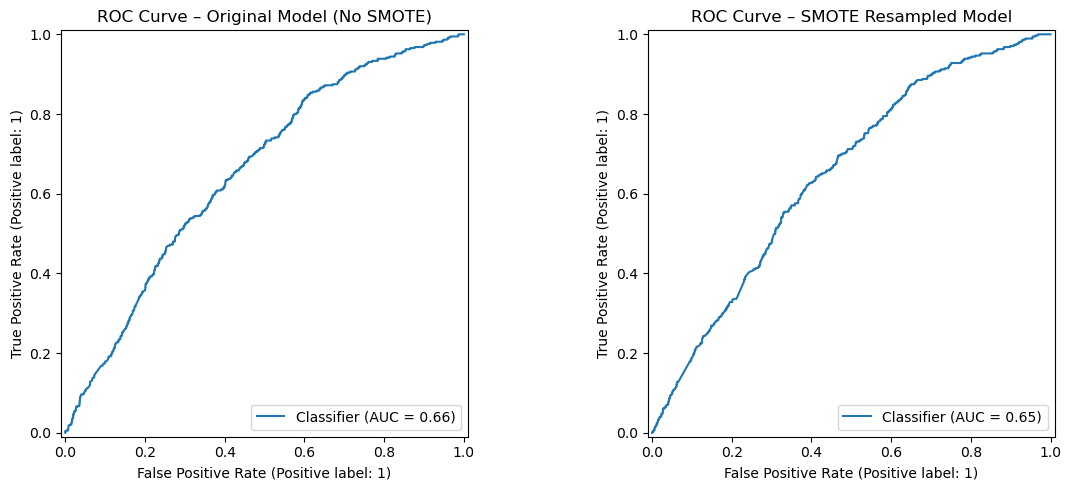

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(y_test, y_test_prob, ax=axes[0])
axes[0].set_title("ROC Curve - Original Model (No SMOTE)")

RocCurveDisplay.from_predictions(y_test, y_smote_prob, ax=axes[1])
axes[1].set_title("ROC Curve - SMOTE Resampled Model")

plt.tight_layout()
plt.show()

### Step 6.7: Side-by-Side Confusion Matrices

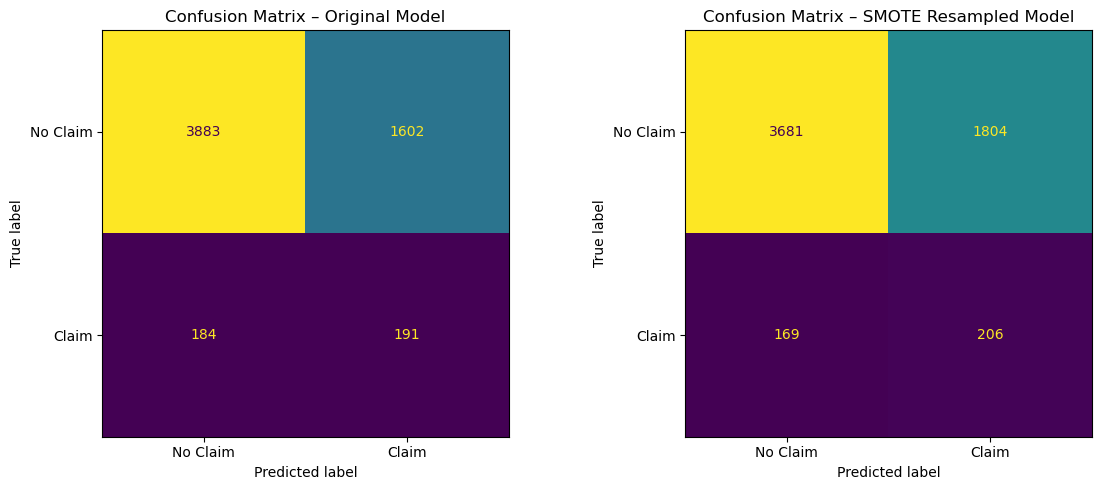

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_test_pred),
    display_labels=["No Claim", "Claim"]
).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix – Original Model")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_smote_pred),
    display_labels=["No Claim", "Claim"]
).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix – SMOTE Resampled Model")

plt.tight_layout()
plt.show()

## Part 7: Feature Selection – Top 15 Features from Original Model Applied to SMOTE

In this section, we investigate whether using only the **Top 15 most important features** (as identified by the original Gradient Boosting model in Step 5.3) can maintain or improve performance when combined with the SMOTE-resampled training set from Part 6.

This approach is motivated by the idea that many features may add noise rather than signal. By restricting the model to only the most predictive features, we may reduce overfitting and improve generalization.

The three-way comparison at the end of this section summarizes the full progression:
- **Original Model** – all features, imbalanced training set
- **SMOTE Model** – all features, resampled training set
- **SMOTE + Top 15 Model** – Top 15 features, resampled training set

### Step 7.1: Extract Top 15 Feature Names from Original Model

In [39]:
# Number of top features to use — easy to change
N = 15

# feat_imp_df was computed in Step 5.3 from the original model
# It is already sorted by importance descending
top_features = feat_imp_df.head(N)["Feature"].tolist()

print(f"Top {N} features selected from original model:")
for i, f in enumerate(top_features, 1):
    print(f"  {i:2}. {f}")

Top 15 features selected from original model:
   1. policy_tenure
   2. age_of_car
   3. height
   4. age_of_policyholder
   5. gross_weight
   6. cylinder
   7. model_M1
   8. max_torque
   9. segment_A
  10. population_density
  11. area_cluster_C18
  12. max_power
  13. area_cluster_C16
  14. displacement
  15. model_M8


### Step 7.2: Slice Training and Test Sets to Top 15 Features

In [40]:
# Retrieve the full list of feature names after preprocessing
# (same logic used in Step 5.3)
cat_feature_names = (
    preprocessor
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_cols)
    .tolist()
)
all_feature_names = numeric_cols + cat_feature_names

# Find the column indices of the Top 15 features
top_indices = [all_feature_names.index(f) for f in top_features]

# Slice X_res (SMOTE resampled, preprocessed) and X_test_processed
X_res_top  = X_res[:, top_indices]
X_test_top = X_test_processed[:, top_indices]

print(f"Reduced training set shape: {X_res_top.shape}")
print(f"Reduced test set shape:     {X_test_top.shape}")

Reduced training set shape: (8373, 15)
Reduced test set shape:     (5860, 15)


### Step 7.3: Train SMOTE Model on Top 15 Features

In [41]:
# Reuse the same best hyperparameters from GridSearchCV
top_model = GradientBoostingClassifier(
    n_estimators=best_params.get("model__n_estimators", 100),
    learning_rate=best_params.get("model__learning_rate", 0.1),
    max_depth=best_params.get("model__max_depth", 3),
    random_state=0
)

top_model.fit(X_res_top, y_res)
print("Top-feature SMOTE model trained successfully.")

Top-feature SMOTE model trained successfully.


### Step 7.4: Threshold Tuning for Top Feature Model

In [31]:
y_top_prob = top_model.predict_proba(X_test_top)[:, 1]

thresholds = np.linspace(0.01, 0.99, 100)
best_top_thresh = 0
best_top_f1 = 0

for t in thresholds:
    preds = (y_top_prob > t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_top_f1:
        best_top_f1 = f1
        best_top_thresh = t

print(f"Best threshold (Top {N} features): {best_top_thresh:.3f}")
print(f"Best F1 (Top {N} features):        {best_top_f1:.4f}")

y_top_pred = (y_top_prob > best_top_thresh).astype(int)

Best threshold (Top 25 features): 0.446
Best F1 (Top 25 features):        0.1700


### Step 7.5: Three-Way Classification Report

In [43]:
print("=" * 45)
print("  Original Model (All Features, No SMOTE)")
print("=" * 45)
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_prob):.4f}")
print(classification_report(y_test, y_test_pred, target_names=["No Claim", "Claim"]))

print("=" * 45)
print("  SMOTE Model (All Features)")
print("=" * 45)
print(f"ROC-AUC: {roc_auc_score(y_test, y_smote_prob):.4f}")
print(classification_report(y_test, y_smote_pred, target_names=["No Claim", "Claim"]))

print("=" * 45)
print(f"  SMOTE + Top {N} Features Model")
print("=" * 45)
print(f"ROC-AUC: {roc_auc_score(y_test, y_top_prob):.4f}")
print(classification_report(y_test, y_top_pred, target_names=["No Claim", "Claim"]))

  Original Model (All Features, No SMOTE)
ROC-AUC: 0.6557
              precision    recall  f1-score   support

    No Claim       0.95      0.71      0.81      5485
       Claim       0.11      0.51      0.18       375

    accuracy                           0.70      5860
   macro avg       0.53      0.61      0.49      5860
weighted avg       0.90      0.70      0.77      5860

  SMOTE Model (All Features)
ROC-AUC: 0.6490
              precision    recall  f1-score   support

    No Claim       0.96      0.67      0.79      5485
       Claim       0.10      0.55      0.17       375

    accuracy                           0.66      5860
   macro avg       0.53      0.61      0.48      5860
weighted avg       0.90      0.66      0.75      5860

  SMOTE + Top 15 Features Model
ROC-AUC: 0.6506
              precision    recall  f1-score   support

    No Claim       0.96      0.65      0.77      5485
       Claim       0.10      0.57      0.17       375

    accuracy                   

### Step 7.6: Three-Way ROC Curves

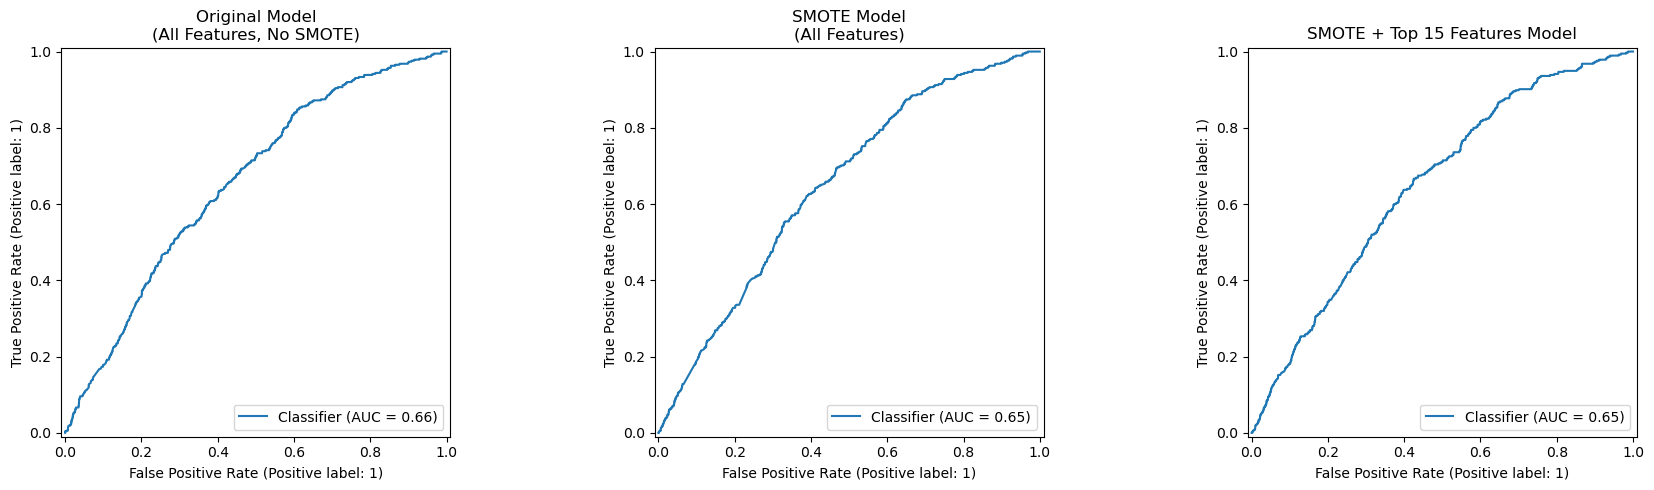

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

RocCurveDisplay.from_predictions(y_test, y_test_prob, ax=axes[0])
axes[0].set_title("Original Model\n(All Features, No SMOTE)")

RocCurveDisplay.from_predictions(y_test, y_smote_prob, ax=axes[1])
axes[1].set_title("SMOTE Model\n(All Features)")

RocCurveDisplay.from_predictions(y_test, y_top_prob, ax=axes[2])
axes[2].set_title(f"SMOTE + Top {N} Features Model")

plt.tight_layout()
plt.show()

### Step 7.7: Three-Way Confusion Matrices

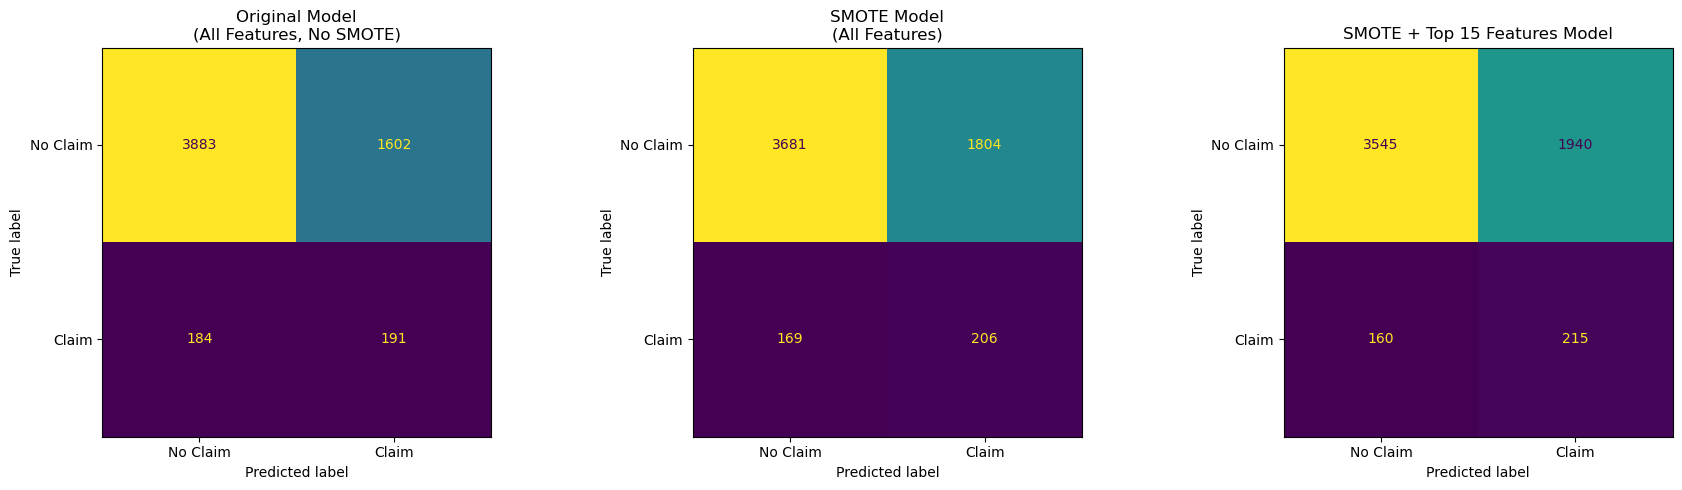

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_test_pred),
    display_labels=["No Claim", "Claim"]
).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Original Model\n(All Features, No SMOTE)")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_smote_pred),
    display_labels=["No Claim", "Claim"]
).plot(ax=axes[1], colorbar=False)
axes[1].set_title("SMOTE Model\n(All Features)")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_top_pred),
    display_labels=["No Claim", "Claim"]
).plot(ax=axes[2], colorbar=False)
axes[2].set_title(f"SMOTE + Top {N} Features Model")

plt.tight_layout()
plt.show()

## Part 8: Conclusion

The main goal of our project was to develop a machine learning system for `PrairieShield Insurance` company to predict if a customer is likely to file a claim. This addresses the client's goal of reducing risks and optimizing pricing.

We started with preprocessing mixed-type dataset, then building a pipeline, developing model and perform evaluation. We have proposed three models: Logistic Regression, Random Forst Classifier and Gradient Boosting Classifier. Among these 3 models the **Gradient Boosing Classifier** acheived the best performance and was chosen as the priamry model. Hyperparameter tuning via GridSearchCV helped us to improve the model and fins the most suitable coefficients. After, we lowered the threshold from baseline 0.5 to 0.08 and increased the recall for the minority (claim) class, even though it resulted in higher number of false positives. 

The final model achieved a ROC-AUC score of 0.6557. The confusion matrix shows that the model is able to identify good amount of true posistive cases, but there is also meaningful amount of false positives due to imbalanced dataset. 

Feature Importance Analysis revealed that policy_tenure, age_of_car, height and age_of_policyholder are strong features for prediction. This information helps to identify key risk drivers. 

The results demonstrate that the machine learning approach is effective in addressing the client's problem of identifying the high-risk customers. However, in the future, we could explore more accurate models for this problem to improve presicion while still maintaining high level of recall.

This project demonstrates the application of machine learning models in data-driven scenarios such as desicion-making in insurance industry.